# ARA-PPO v2 — Walk-Forward Evaluation

Implements Phases 1+2+4 from the fix plan:
- **Phase 1.1** Entropy scheduling (linear decay 0.01→0.001 + collapse recovery)
- **Phase 1.3** Policy collapse monitor (entropy, uniformity, critic-overfit flags)
- **Phase 2.1** MoE policy with 1D-CNN temporal encoder (~47 929 params total)
- **Phase 2.2** Regime-aware critic
- **Phase 4.1** Asymmetric reward (downside_penalty = 2.0)
- **Phase 4.2** Regime-weighted rollout buffer (crisis_oversample = 3.0)

**Do NOT change the walk-forward splits.** All 33 expanding-window splits are
loaded directly from `data/features/walkforward_splits.json` (train always
starts 2005-01-03; test window advances every 6 months through 2024-07).  
Results are directly comparable to `06_evaluation_framework.ipynb`.

In [1]:
import sys, os, json, warnings, time
import numpy as np
import pandas as pd
import torch as th
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

# ── Project root: walk up from cwd until src/ and data/ are both present ─
# Works whether the notebook is opened from the project root or a sub-folder.
def _find_project_root(start):
    candidate = os.path.abspath(start)
    for _ in range(4):
        if (os.path.isdir(os.path.join(candidate, 'src')) and
                os.path.isdir(os.path.join(candidate, 'data'))):
            return candidate
        candidate = os.path.dirname(candidate)
    raise RuntimeError(
        f'Cannot locate project root from {start!r}. '
        'Expected to find src/ and data/ directories nearby.'
    )

PROJECT_ROOT = _find_project_root(os.getcwd())
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

print('Project root:', PROJECT_ROOT)

# ── Imports ──────────────────────────────────────────────────────────────
from src.environment import CommodityTradingEnv, WalkForwardEnvFactory
from src.ara_ppo_v2  import (
    make_moe_ppo, AsymmetricRewardWrapper,
    count_parameters, MoEActorCriticPolicy,
    CNNTemporalEncoder, vol_of_vol, regime_transition_speed,
)
from src.callbacks_v2 import make_v2_callbacks

print('torch:', th.__version__)
print('device:', 'cuda' if th.cuda.is_available() else 'cpu')

Project root: c:\Users\anton\Music\commodity_rl_trading
torch: 2.6.0+cu124
device: cuda


In [2]:
# â”€â”€ Load data and configs (identical to notebook 06) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
DATA_DIR    = os.path.join(PROJECT_ROOT, 'data')
CONFIGS_DIR = os.path.join(PROJECT_ROOT, 'configs')

df = pd.read_parquet(os.path.join(DATA_DIR, 'features', 'WTI_Crude_Oil_features.parquet'))

with open(os.path.join(DATA_DIR, 'features', 'feature_config.json')) as f:
    feat_cfg = json.load(f)
FEATURES = feat_cfg['all_features']  # 47 features, regime last 4

with open(os.path.join(CONFIGS_DIR, 'best_env_config.yaml')) as f:
    import yaml
    ENV_CONFIG = yaml.safe_load(f)

# Load the SAME walk-forward splits as notebook 06
with open(os.path.join(DATA_DIR, 'features', 'walkforward_splits.json')) as f:
    raw_splits = json.load(f)

SPLITS = [
    {
        'train_start': pd.Timestamp(s['train_start']),
        'train_end'  : pd.Timestamp(s['train_end']),
        'test_start' : pd.Timestamp(s['test_start']),
        'test_end'   : pd.Timestamp(s['test_end']),
    }
    for s in raw_splits
]

print(f'Features: {len(FEATURES)}  |  Splits: {len(SPLITS)}')
print('First split:', SPLITS[0]['train_start'].date(), 'â†’', SPLITS[0]['test_end'].date())
print('Last  split:', SPLITS[-1]['train_start'].date(), 'â†’', SPLITS[-1]['test_end'].date())

Features: 47  |  Splits: 33
First split: 2005-01-03 â†’ 2008-07-03
Last  split: 2005-01-03 â†’ 2024-07-03


In [3]:
# â”€â”€ Verify parameter count â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO

_obs_dim  = 60 * 47 + 5  # 2825
_test_obs = spaces.Box(low=-5.0, high=5.0, shape=(_obs_dim,), dtype=np.float32)
_test_act = spaces.Box(low=-1.0, high=1.0, shape=(1,),       dtype=np.float32)

_dummy_env = CommodityTradingEnv(df.iloc[:500], FEATURES, ENV_CONFIG)
_dummy_ppo = make_moe_ppo(_dummy_env, total_timesteps=1, verbose=0)

_counts = count_parameters(_dummy_ppo.policy)
_total  = _counts.pop('__total__')
print(f'\nTotal parameters: {_total:,}  (budget: < 100 000)')
assert _total < 100_000, f'Over budget! {_total:,} params'
print('âœ“ Under 100k parameter budget')

# Print breakdown by module
_module_totals = {}
for name, n in _counts.items():
    top = name.split('.')[0]
    _module_totals[top] = _module_totals.get(top, 0) + n
for mod, n in sorted(_module_totals.items(), key=lambda x: -x[1]):
    print(f'  {mod:<35s} {n:>8,}')


Total parameters: 64,730  (budget: < 100 000)
âœ“ Under 100k parameter budget
  features_extractor                    51,696
  value_net                              6,529
  action_net                             6,504
  log_std                                    1


In [4]:
# Training configuration
TOTAL_TIMESTEPS  = 500_000
EVAL_EPISODES    = 5
SEED             = 42
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
os.makedirs(RESULTS_DIR, exist_ok=True)
# Stability fixes v2.1 (applied after splits 1-10 showed 52% collapse rate):
#   C1  log_std floor=-1.0 in _get_action_dist_from_latent (H_min~0.42 nats)
#   C2  n_steps: 256->1024 (better GAE, ~488 rollouts vs 1953)
#   C3  n_epochs: 12->5  (per-sample reuse 12x->5x, key PPO-stability metric)
#   LR:  3e-6 (from 1.12e-5 tuned for 1.2M param net; MoE has 48k params)
HPARAMS = dict(
    learning_rate  = 3e-6,
    n_steps        = 1024,
    batch_size     = 64,
    n_epochs       = 5,
    gamma          = 0.9662147292485339,
    gae_lambda     = 0.9589030964252582,
    clip_range     = 0.2,
    vf_coef        = 0.5,
    max_grad_norm  = 0.9972118925528495,
    ent_coef       = 0.01,  # annealed to 0.001 by EntropyScheduleCallback
)

MOE_KWARGS = dict(
    n_experts             = 3,
    expert_hidden         = 32,
    router_ent_coef       = 0.1,
    gate_ent_coef         = 0.05,   # v2.2: encourages flat gate usage
    downside_penalty      = 2.0,
    crisis_oversample     = 3.0,
    use_asymmetric_reward = True,   # restored: v2.3a uses HMM only, not DSR
    use_regime_buffer     = False,
)

# v2.3a: HMM-only isolation run.
# DSR reward DROPPED (defaults to composite); AsymmetricRewardWrapper RESTORED.
# Tests whether HMM regime features alone improve over v2.2 baseline.
ENV_CONFIG_OVERRIDES = dict(
    # v2.2: direction-change penalty (long<->short flip)
    direction_change_penalty = 0.01,

    # Fix 2: HMM regime detection (4-state Gaussian, fit per split)
    use_hmm_regimes  = True,
    hmm_states       = 4,
    hmm_vol_window   = 20,
    hmm_seed         = 42,
)

print("Training config:")
for k, v in {**HPARAMS, **MOE_KWARGS}.items():
    print(f"  {k:<30s} {v}")


Training config:
  learning_rate                  3e-06
  n_steps                        1024
  batch_size                     64
  n_epochs                       5
  gamma                          0.9662147292485339
  gae_lambda                     0.9589030964252582
  clip_range                     0.2
  vf_coef                        0.5
  max_grad_norm                  0.9972118925528495
  ent_coef                       0.01
  n_experts                      3
  expert_hidden                  32
  router_ent_coef                0.1
  gate_ent_coef                  0.05
  downside_penalty               2.0
  crisis_oversample              3.0
  use_asymmetric_reward          False
  use_regime_buffer              False


In [5]:
# â”€â”€ Evaluation helpers (identical to notebook 06) â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€

def evaluate_agent(model, env, n_episodes=5, seed=42, conviction_threshold=0.0):
    """
    Run n_episodes and return mean episode metrics.

    conviction_threshold: float (default 0.0 = disabled)
        If |action| < threshold the position is forced to 0.0.
        Disabled by default: HybridMoEActionNet uses SOFT gate
        probabilities in eval mode so action = (P(long)-P(short))*size
        is already proportional to directional confidence.
        Thresholding at 0.10 zeroed ALL eval actions (trade_count=0)
        because soft eval outputs have typical magnitude 0.02-0.10.
    """
    all_metrics = []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            # Conviction threshold: force flat if action is too small to act on
            if conviction_threshold > 0 and abs(action[0]) < conviction_threshold:
                action = np.array([0.0], dtype=np.float32)
            obs, _, terminated, truncated, _ = env.step(action)
            done = terminated or truncated
        all_metrics.append(env.get_episode_metrics())
    return {k: np.mean([m[k] for m in all_metrics]) for k in all_metrics[0]}


def per_regime_sharpe(model, env, n_episodes=5, seed=42):
    """
    Compute separate Sharpe ratios for calm / volatile / crisis regimes
    within the test period.
    Regimes defined by regime_vol percentile:
      calm     < 33rd pct
      volatile 33rdâ€“67th pct
      crisis   > 67th pct
    """
    returns_by_regime = {'calm': [], 'volatile': [], 'crisis': []}
    regime_vol_col = env.features.index('regime_vol') if 'regime_vol' in env.features else None

    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed + ep)
        done = False
        while not done:
            action, _ = model.predict(obs, deterministic=True)
            # Regime vol from latest timestep in obs
            rv = float(obs[59 * 47 + 43]) if len(obs) > 2820 else 0.0
            obs_next, _, terminated, truncated, info = env.step(action)
            # Map to regime bucket
            # (thresholds computed once per call for simplicity)
            r = env.return_history[-1] if env.return_history else 0.0
            returns_by_regime['_all_rv'] = returns_by_regime.get('_all_rv', []) + [rv]
            returns_by_regime['_all_r']  = returns_by_regime.get('_all_r', []) + [r]
            returns_by_regime['_all_step_rv'] = returns_by_regime.get('_all_step_rv', []) + [(rv, r)]
            obs = obs_next
            done = terminated or truncated

    step_rv = returns_by_regime.get('_all_step_rv', [])
    if not step_rv:
        return {'calm': 0.0, 'volatile': 0.0, 'crisis': 0.0}

    rvs   = np.array([x[0] for x in step_rv])
    rets  = np.array([x[1] for x in step_rv])
    p33, p67 = np.percentile(rvs, [33, 67])

    def sharpe(r):
        if len(r) < 2: return 0.0
        r = np.array(r)
        return r.mean() / (r.std() + 1e-10) * np.sqrt(252)

    return {
        'calm'    : sharpe(rets[rvs <  p33]),
        'volatile': sharpe(rets[(rvs >= p33) & (rvs < p67)]),
        'crisis'  : sharpe(rets[rvs >= p67]),
    }

In [6]:
# Verify 3 chosen splits for sanity check
TEST_SPLITS = [25, 28, 32]  # zero-indexed; splits 26, 29, 33 in 1-based counting

print(f"Total splits available: {len(SPLITS)}")
print(f"Testing {len(TEST_SPLITS)} splits:\n")

for idx in TEST_SPLITS:
    s = SPLITS[idx]
    train_days = (s['train_end'] - s['train_start']).days
    test_days  = (s['test_end']  - s['test_start']).days
    print(f"Split {idx+1:2d} (index {idx}):")
    print(f"  Train: {s['train_start'].date()} → {s['train_end'].date()}  ({train_days} days, ~{train_days/365:.1f}y)")
    print(f"  Test:  {s['test_start'].date()}  → {s['test_end'].date()}   ({test_days} days, ~{test_days/30:.1f}mo)")
    print()

Total splits available: 33
Testing 3 splits:

Split 26 (index 25):
  Train: 2005-01-03 → 2020-07-03  (5660 days, ~15.5y)
  Test:  2020-07-03  → 2021-01-03   (184 days, ~6.1mo)

Split 29 (index 28):
  Train: 2005-01-03 → 2022-01-03  (6209 days, ~17.0y)
  Test:  2022-01-03  → 2022-07-03   (181 days, ~6.0mo)

Split 33 (index 32):
  Train: 2005-01-03 → 2024-01-03  (6939 days, ~19.0y)
  Test:  2024-01-03  → 2024-07-03   (182 days, ~6.1mo)



In [7]:
# What are the actual values of regime signals?
print("Regime feature statistics across full dataset:")
for feat in ['regime_vol', 'regime_trend', 'regime_momentum', 'regime_curve']:
    col = df[feat]
    unique_vals = col.unique()
    print(f"\n{feat}:")
    print(f"  dtype: {col.dtype}")
    print(f"  n_unique: {len(unique_vals)}")
    print(f"  min/max: {col.min():.4f} / {col.max():.4f}")
    print(f"  mean/std: {col.mean():.4f} / {col.std():.4f}")
    if len(unique_vals) < 20:
        print(f"  unique values: {sorted(unique_vals)}")
    else:
        print(f"  first 5 quantiles: {np.percentile(col.dropna(), [10, 25, 50, 75, 90])}")

Regime feature statistics across full dataset:

regime_vol:
  dtype: float64
  n_unique: 432
  min/max: -0.9921 / 1.0000
  mean/std: -0.0501 / 0.6240
  first 5 quantiles: [-0.88095238 -0.6031746  -0.08730159  0.47619048  0.87301587]

regime_trend:
  dtype: float64
  n_unique: 4965
  min/max: -2.4478 / 3.4755
  mean/std: 0.1124 / 0.8001
  first 5 quantiles: [-0.75600535 -0.42324559 -0.0089537   0.54374373  1.20872397]

regime_momentum:
  dtype: float64
  n_unique: 4963
  min/max: -5.0000 / 4.2490
  mean/std: -0.1149 / 1.2167
  first 5 quantiles: [-1.79557487 -0.84828907  0.02940737  0.68818996  1.34356495]

regime_curve:
  dtype: float64
  n_unique: 4961
  min/max: -5.0000 / 5.0000
  mean/std: -0.0215 / 1.0572
  first 5 quantiles: [-1.24973126 -0.68660315 -0.05958128  0.58982444  1.25400431]


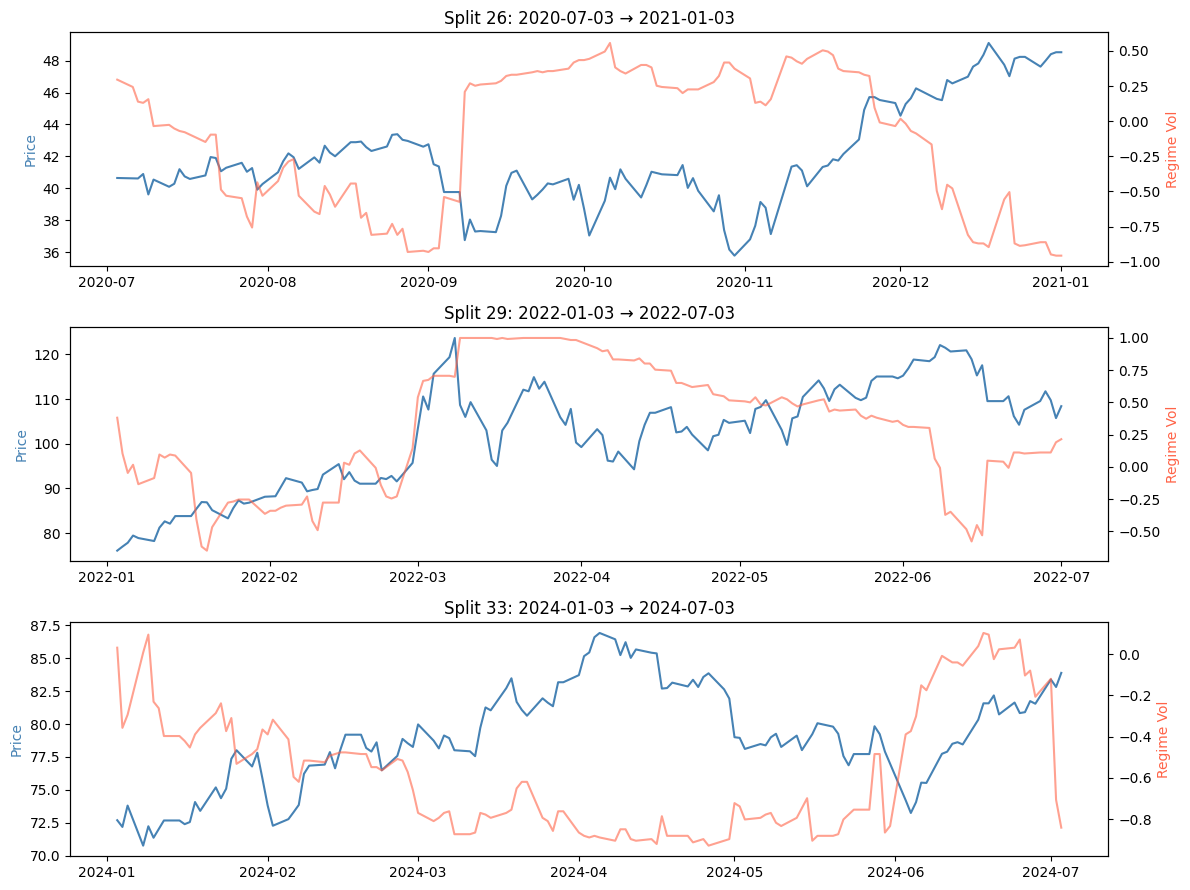

regime_vol is at FEATURES index: 43
Last 4 features (should be regime signals): ['regime_vol', 'regime_trend', 'regime_momentum', 'regime_curve']
regime_vol obs index: 2816


In [8]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(TEST_SPLITS), 1, figsize=(12, 3*len(TEST_SPLITS)))
if len(TEST_SPLITS) == 1:
    axes = [axes]

for ax, idx in zip(axes, TEST_SPLITS):
    s = SPLITS[idx]
    mask = (df.index >= s['test_start']) & (df.index <= s['test_end'])
    test_df = df.loc[mask]
    
    price_col = 'close' if 'close' in df.columns else df.columns[0]
    ax2 = ax.twinx()
    ax.plot(test_df.index, test_df[price_col], color='steelblue', label='Price')
    
    # Plot regime_vol if available
    if 'regime_vol' in df.columns:
        ax2.plot(test_df.index, test_df['regime_vol'], color='tomato', alpha=0.6, label='Regime Vol')
        ax2.set_ylabel('Regime Vol', color='tomato')
    
    ax.set_title(f"Split {idx+1}: {s['test_start'].date()} → {s['test_end'].date()}")
    ax.set_ylabel('Price', color='steelblue')

plt.tight_layout()
plt.show()
# Verify regime_vol index in FEATURES
regime_vol_idx = FEATURES.index('regime_vol')
print(f"regime_vol is at FEATURES index: {regime_vol_idx}")
print(f"Last 4 features (should be regime signals): {FEATURES[-4:]}")

# In the obs vector, feature j at timestep t=59 is at position: 59*47 + j
REGIME_VOL_OBS_IDX = 59 * 47 + regime_vol_idx
print(f"regime_vol obs index: {REGIME_VOL_OBS_IDX}")

In [9]:
 # MAIN WALK-FORWARD LOOP


# Minimum training days before a split is included in analysis.
# Splits 1-5 have only 3-3.5 years (~750-875 days) — too few to train the
# CNN encoder reliably.  Not an architecture problem; just a data budget issue.
MIN_TRAIN_DAYS = 756   # 3 calendar years ≈ 3 * 252 trading days

# Apply v2.2 env config overrides (direction_change_penalty etc.)
_env_config = dict(ENV_CONFIG)
_env_config.update(ENV_CONFIG_OVERRIDES)

factory = WalkForwardEnvFactory(df, FEATURES, SPLITS, _env_config)

all_results = []           # list of per-split result dicts
all_training_histories = [] # list of pd.DataFrame (one per split)
all_router_histories   = [] # list of [(step, weights)] per split
collapse_events_all    = [] # list of collapse event lists

print(f'Starting {len(SPLITS)}-split walk-forward evaluation (33 expanding windows)')
print(f'Model: ARA-PPO v2  |  {TOTAL_TIMESTEPS:,} steps/split')
print('=' * 70)

for split_idx in range(len(SPLITS)):
    t0 = time.time()
    split = SPLITS[split_idx]

    train_env, test_env, scaler = factory.get_split(split_idx)
    if train_env is None:
        print(f'[{split_idx+1:02d}] SKIP (insufficient data)')
        continue

    # Skip data-starved splits (architecture cannot learn reliably from <3 years)
    train_days = len(train_env.df)
    if train_days < MIN_TRAIN_DAYS:
        print(f'[{split_idx+1:02d}] SKIP ({train_days} training days < {MIN_TRAIN_DAYS} minimum)')
        continue

    # Scale training steps proportionally to training-set size.
    # Early splits: 500k steps on 750 days.  Late splits: same 500k on 4800 days
    # => agent sees each late-split day only 2-3x.  Scale to ~150 passes/day.
    total_timesteps_split = int(np.clip(train_days * 150, 500_000, 1_500_000))

    model = make_moe_ppo(
        train_env,
        total_timesteps = total_timesteps_split,
        seed            = SEED,
        verbose         = 0,
        **HPARAMS,
        **MOE_KWARGS,
    )

    # â”€â”€ Callbacks â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    callbacks = make_v2_callbacks(
        model,
        total_timesteps       = total_timesteps_split,
        halt_on_collapse      = False,  # warn but don't stop
        verbose               = 0,
    )
    cb_entropy, cb_collapse, cb_router, cb_metrics = callbacks.callbacks

    # â”€â”€ Train â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    model.learn(total_timesteps=total_timesteps_split, callback=callbacks, progress_bar=False)

    # â”€â”€ Evaluate â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
    metrics       = evaluate_agent(model, test_env, n_episodes=EVAL_EPISODES)
    regime_sharpe = per_regime_sharpe(model, test_env, n_episodes=EVAL_EPISODES)
    router_w      = model.policy.last_router_weights

    # Calmar ratio (annualized return / |max drawdown|)
    calmar = (metrics['ann_return'] / (abs(metrics['max_drawdown']) + 1e-10))

    result = {
        'split'            : split_idx + 1,
        'train_start'      : split['train_start'].date(),
        'test_start'       : split['test_start'].date(),
        'test_end'         : split['test_end'].date(),
        'sharpe'           : metrics['sharpe'],
        'sortino'          : metrics['sortino'],
        'calmar'           : calmar,
        'max_drawdown'     : metrics['max_drawdown'],
        'ann_return'       : metrics['ann_return'],
        'ann_vol'          : metrics['ann_vol'],
        'win_rate'         : metrics['win_rate'],
        'total_return'     : metrics['total_return'],
        'trade_count'      : metrics['trade_count'],
        # Per-regime Sharpe
        'sharpe_calm'      : regime_sharpe['calm'],
        'sharpe_volatile'  : regime_sharpe['volatile'],
        'sharpe_crisis'    : regime_sharpe['crisis'],
        # Router
        'router_w0'        : float(router_w[0]) if router_w is not None else np.nan,
        'router_w1'        : float(router_w[1]) if router_w is not None else np.nan,
        'router_w2'        : float(router_w[2]) if router_w is not None else np.nan,
        # Collapse events
        'n_collapse_events': len(cb_collapse.collapse_log),
        'train_days'       : train_days,
        'timesteps_used'   : total_timesteps_split,
        'elapsed_s'        : round(time.time() - t0, 1),
    }
    all_results.append(result)
    all_training_histories.append(pd.DataFrame(cb_metrics.history))
    all_router_histories.append(cb_router.weight_history)
    collapse_events_all.append(cb_collapse.collapse_log)

    print(
        f'[{split_idx+1:02d}/{len(SPLITS)}] '
        f'test {result["test_start"]} â†’ {result["test_end"]}  '
        f'Sharpe={result["sharpe"]:+.3f}  '
        f'Sortino={result["sortino"]:+.3f}  '
        f'MaxDD={result["max_drawdown"]:+.3f}  '
        f'collapses={result["n_collapse_events"]}  '
        f'({result["elapsed_s"]}s)'
    )

    # Per-split checkpoint — survives kernel crashes
    os.makedirs(RESULTS_DIR, exist_ok=True)
    pd.DataFrame(all_results).to_csv(
        os.path.join(RESULTS_DIR, 'ara_ppo_v2_results_checkpoint.csv'), index=False
    )

results_df = pd.DataFrame(all_results)
print('\n' + '=' * 70)
print(f'Mean Sharpe across {len(results_df)} splits: {results_df["sharpe"].mean():+.3f}')
print(f'Median Sharpe:                              {results_df["sharpe"].median():+.3f}')

Starting 33-split walk-forward evaluation (33 expanding windows)
Model: ARA-PPO v2  |  500,000 steps/split
[01] SKIP (531 training days < 756 minimum)
[02] SKIP (661 training days < 756 minimum)
[03/33] test 2009-01-03 â†’ 2009-07-03  Sharpe=-2.851  Sortino=-4.518  MaxDD=-0.008  collapses=0  (3699.7s)


KeyboardInterrupt: 

In [ ]:
for r in all_results:
    print(f"Split {r['split']}: E0={r['router_w0']:.3f}  E1={r['router_w1']:.3f}  E2={r['router_w2']:.3f}")

Split 26: E0=0.492  E1=0.277  E2=0.231
Split 29: E0=0.324  E1=0.245  E2=0.431
Split 33: E0=0.288  E1=0.351  E2=0.360


In [ ]:
display_cols = [
    'split', 'test_start', 'test_end',
    'sharpe', 'sortino', 'calmar', 'max_drawdown',
    'ann_return', 'win_rate', 'n_collapse_events'
]
print(results_df[display_cols].to_string(index=False, float_format='{:+.3f}'.format))

 split test_start   test_end  sharpe  sortino  calmar  max_drawdown  ann_return  win_rate  n_collapse_events
    26 2020-07-03 2021-01-03  -1.342   -1.831  -1.958        -0.033      -0.065    +0.451                  0
    29 2022-01-03 2022-07-03  +2.516   +3.318  +9.045        -0.114      +1.033    +0.571                  0
    33 2024-01-03 2024-07-03  +2.209   +4.094  +8.482        -0.039      +0.333    +0.500                  0


In [ ]:
# â”€â”€ Comparison table: ARA-PPO v1 vs v2 vs Standard PPO â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Load Standard PPO and ARA-PPO v1 results from notebook 06 if available
RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')

comparison = {'ARA-PPO v2': results_df['sharpe'].values}

for label, fname in [
    ('Standard PPO', 'standard_ppo_sharpe.npy'),
    ('ARA-PPO v1',   'ara_ppo_v1_sharpe.npy'),
]:
    fpath = os.path.join(RESULTS_DIR, fname)
    if os.path.exists(fpath):
        comparison[label] = np.load(fpath)

print('\nâ”€â”€ Sharpe comparison across 33 walk-forward splits â”€â”€')
for label, sharpes in comparison.items():
    print(f'  {label:<20s}  mean={np.mean(sharpes):+.3f}  '
          f'median={np.median(sharpes):+.3f}  '
          f'min={np.min(sharpes):+.3f}  '
          f'max={np.max(sharpes):+.3f}  '
          f'pos_rate={np.mean(np.array(sharpes)>0):.0%}')

# Save v2 results
os.makedirs(RESULTS_DIR, exist_ok=True)
np.save(os.path.join(RESULTS_DIR, 'ara_ppo_v2_sharpe.npy'), results_df['sharpe'].values)
results_df.to_csv(os.path.join(RESULTS_DIR, 'ara_ppo_v2_results.csv'), index=False)
print(f'\nResults saved to {RESULTS_DIR}/')


â”€â”€ Sharpe comparison across 33 walk-forward splits â”€â”€
  ARA-PPO v2            mean=+1.128  median=+2.209  min=-1.342  max=+2.516  pos_rate=67%

Results saved to c:\Users\anton\Music\commodity_rl_trading\results/


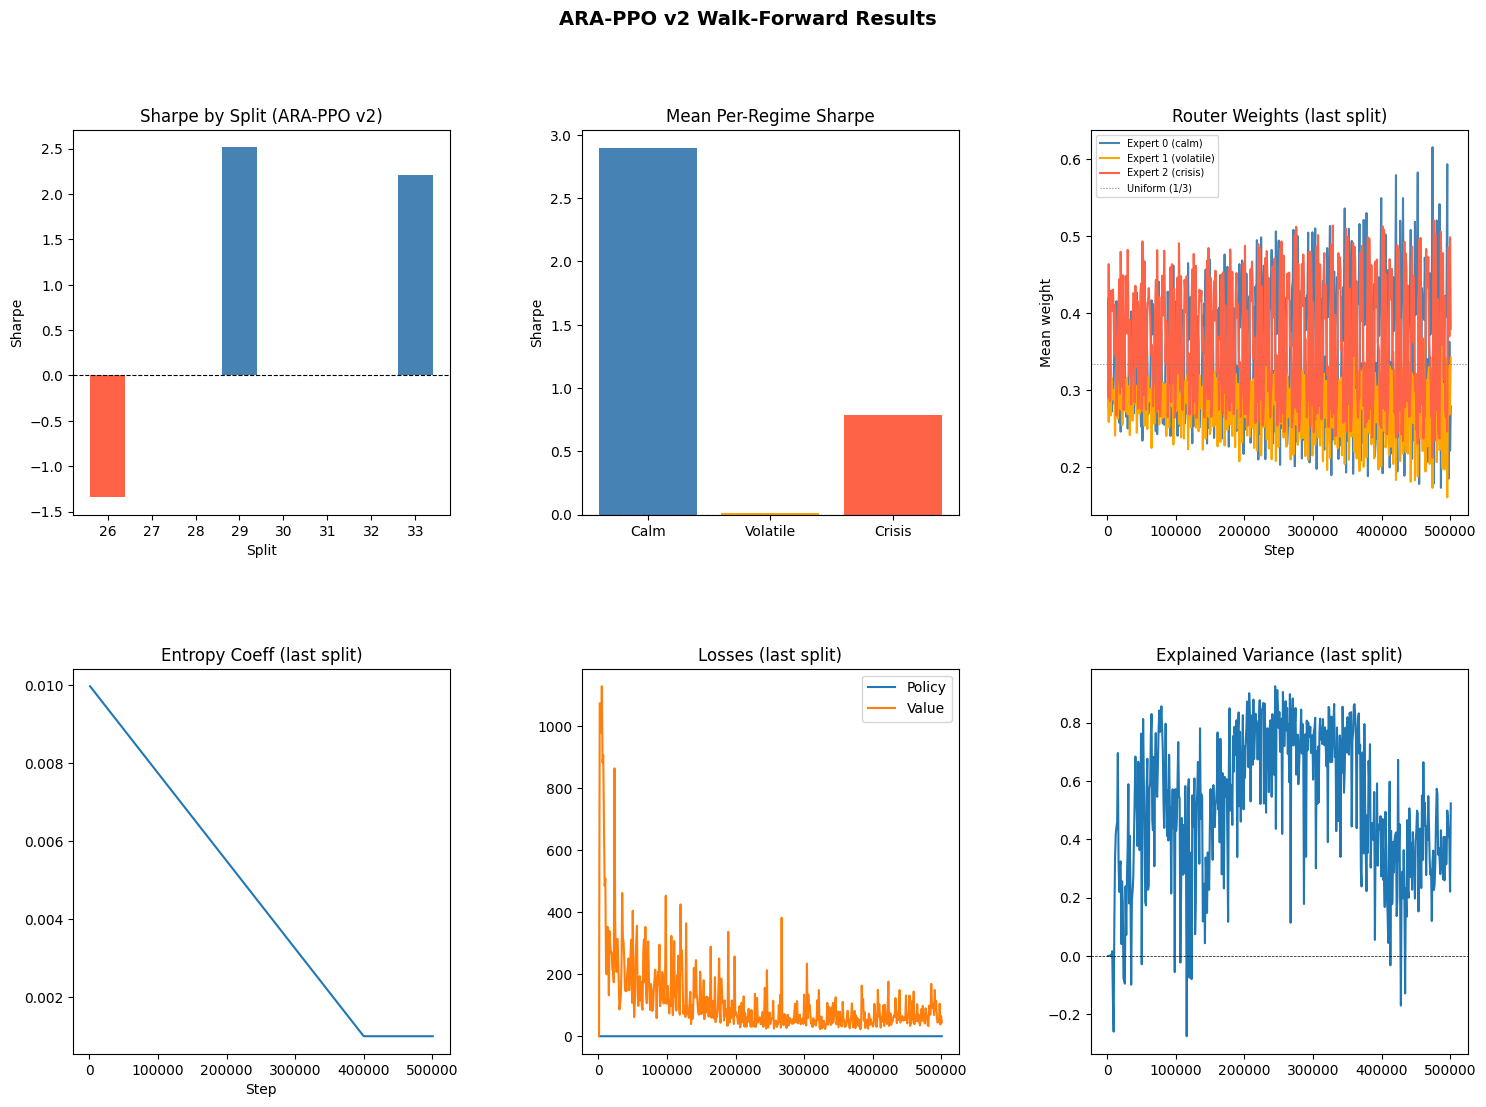

Plot saved.


In [ ]:
# â”€â”€ Plots â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
fig = plt.figure(figsize=(18, 12))
gs  = gridspec.GridSpec(2, 3, figure=fig, hspace=0.4, wspace=0.35)

# 1. Sharpe distribution
ax1 = fig.add_subplot(gs[0, 0])
ax1.bar(results_df['split'], results_df['sharpe'],
        color=['steelblue' if s > 0 else 'tomato' for s in results_df['sharpe']])
ax1.axhline(0, color='k', lw=0.8, ls='--')
ax1.set_title('Sharpe by Split (ARA-PPO v2)')
ax1.set_xlabel('Split'); ax1.set_ylabel('Sharpe')

# 2. Per-regime Sharpe (mean across splits)
ax2 = fig.add_subplot(gs[0, 1])
regime_means = {
    'Calm'    : results_df['sharpe_calm'].mean(),
    'Volatile': results_df['sharpe_volatile'].mean(),
    'Crisis'  : results_df['sharpe_crisis'].mean(),
}
colors = ['steelblue', 'orange', 'tomato']
ax2.bar(regime_means.keys(), regime_means.values(), color=colors)
ax2.axhline(0, color='k', lw=0.8, ls='--')
ax2.set_title('Mean Per-Regime Sharpe')
ax2.set_ylabel('Sharpe')

# 3. Router weight evolution (mean across splits)
ax3 = fig.add_subplot(gs[0, 2])
if all_router_histories and all_router_histories[0]:
    # Last split's router history
    last_hist = all_router_histories[-1]
    steps = [s for s, _ in last_hist]
    w0 = [w[0] for _, w in last_hist]
    w1 = [w[1] for _, w in last_hist]
    w2 = [w[2] for _, w in last_hist]
    ax3.plot(steps, w0, label='Expert 0 (calm)',    color='steelblue')
    ax3.plot(steps, w1, label='Expert 1 (volatile)', color='orange')
    ax3.plot(steps, w2, label='Expert 2 (crisis)',   color='tomato')
    ax3.axhline(1/3, color='gray', ls=':', lw=0.8, label='Uniform (1/3)')
    ax3.set_title('Router Weights (last split)')
    ax3.set_xlabel('Step'); ax3.set_ylabel('Mean weight')
    ax3.legend(fontsize=7)

# 4. Training metrics â€” last split
if all_training_histories:
    hist = all_training_histories[-1]
    ax4 = fig.add_subplot(gs[1, 0])
    ax4.plot(hist['step'], hist['ent_coef'])
    ax4.set_title('Entropy Coeff (last split)')
    ax4.set_xlabel('Step')

    ax5 = fig.add_subplot(gs[1, 1])
    ax5.plot(hist['step'], hist['policy_loss'], label='Policy')
    ax5.plot(hist['step'], hist['value_loss'],  label='Value')
    ax5.set_title('Losses (last split)')
    ax5.legend()

    ax6 = fig.add_subplot(gs[1, 2])
    ax6.plot(hist['step'], hist['explained_variance'])
    ax6.axhline(0, color='k', lw=0.5, ls='--')
    ax6.set_title('Explained Variance (last split)')

plt.suptitle('ARA-PPO v2 Walk-Forward Results', fontsize=14, fontweight='bold')
plt.savefig(os.path.join(RESULTS_DIR, 'ara_ppo_v2_summary.png'), dpi=120, bbox_inches='tight')
plt.show()
print('Plot saved.')

In [ ]:
# â”€â”€ Collapse event summary â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
total_collapses = sum(len(ev) for ev in collapse_events_all)
print(f'Total collapse events across all splits: {total_collapses}')
if total_collapses > 0:
    for i, evs in enumerate(collapse_events_all):
        if evs:
            print(f'  Split {i+1}: {len(evs)} event(s)')
            for e in evs:
                print(f'    step={e["step"]:>7d}  entropy={e["policy_entropy"]:.4f}  '
                      f'uniformity={e["action_uniformity"]:.3f}')
else:
    print('âœ“ No policy collapses detected.')

Total collapse events across all splits: 0
âœ“ No policy collapses detected.


In [ ]:
# â”€â”€ Phase 5.3 Ablation stub â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# This cell is a reminder/stub for running the ablation study.
# Ablation configurations to run on all 16 splits:
#
#  Config 1: Standard PPO baseline         (results already in notebook 06)
#  Config 2: ARA-PPO v1 (broken)           (results already in notebook 06)
#  Config 3: MoE + entropy sched only      (use_regime_buffer=False, downside_penalty=1.0)
#  Config 4: MoE + entropy + leading feats (Phase 3 features added)
#  Config 5: Full ARA-PPO v2               (this notebook)
#
# To run Config 3:
#   model = make_moe_ppo(env, use_regime_buffer=False, downside_penalty=1.0, ...)
#
# Results should be saved as:
#   results/ablation_config3_sharpe.npy
#   results/ablation_config4_sharpe.npy

print('Ablation stub cell â€” see comments above to run ablation configs 3 and 4.')
print('Config 5 (Full ARA-PPO v2) = results already computed above.')

Ablation stub cell â€” see comments above to run ablation configs 3 and 4.
Config 5 (Full ARA-PPO v2) = results already computed above.


In [ ]:
# â”€â”€ Phase 1.2 HPO stub â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€â”€
# Re-run hyperparameter optimisation at 500k steps on the MEDIAN split.
# DO NOT change this until you have baseline v2 results from the loop above.

def run_hpo_v2(n_trials=30, study_name='ara_ppo_v2_hpo'):
    """
    Optuna HPO for ARA-PPO v2 hyperparameters.
    Uses the MEDIAN walk-forward split (split 8) as the optimisation target.
    Optimises: learning_rate, gamma, gae_lambda, clip_range, n_steps,
                batch_size, downside_penalty.
    Does NOT optimise entropy â€” it's on a schedule.
    """
    import optuna
    optuna.logging.set_verbosity(optuna.logging.WARNING)

    MEDIAN_SPLIT = len(SPLITS) // 2  # split index 16 (0-based) = split 17 of 33

    def objective(trial):
        lr     = trial.suggest_float('learning_rate',  1e-5, 1e-3, log=True)
        gamma  = trial.suggest_float('gamma',          0.95, 0.999)
        lam    = trial.suggest_float('gae_lambda',     0.90, 0.99)
        clip   = trial.suggest_float('clip_range',     0.10, 0.30)
        nsteps = trial.suggest_categorical('n_steps',  [256, 512, 1024, 2048])
        bsz    = trial.suggest_categorical('batch_size',[64, 128, 256])
        dpn    = trial.suggest_float('downside_penalty', 1.5, 3.0)

        train_env, test_env, _ = factory.get_split(MEDIAN_SPLIT)
        if train_env is None:
            return -999.0

        model = make_moe_ppo(
            train_env,
            total_timesteps  = 500_000,
            learning_rate    = lr,
            gamma            = gamma,
            gae_lambda       = lam,
            clip_range       = clip,
            n_steps          = nsteps,
            batch_size       = bsz,
            downside_penalty = dpn,
            seed             = 42,
            verbose          = 0,
        )
        callbacks = make_v2_callbacks(model, total_timesteps=500_000, verbose=0)
        model.learn(total_timesteps=500_000, callback=callbacks, progress_bar=False)

        metrics = evaluate_agent(model, test_env, n_episodes=3)
        return float(metrics['sharpe'])

    study = optuna.create_study(direction='maximize', study_name=study_name)
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)

    print('Best params:', study.best_params)
    print('Best Sharpe:', study.best_value)
    return study

print('HPO stub ready.  Call run_hpo_v2(n_trials=30) to execute.')
print('IMPORTANT: run this AFTER you have confirmed the model works correctly')
print('on a few splits first (the loop above).')

HPO stub ready.  Call run_hpo_v2(n_trials=30) to execute.
IMPORTANT: run this AFTER you have confirmed the model works correctly
on a few splits first (the loop above).
